In [40]:
import matplotlib.pyplot as plt
import re
import pandas as pd

# Accessing Storage Files: Bronze → Silver
Explore how to access and manipulate job files stored in the bronze and silver layers using `get_storage_from_env()` and the project environment configuration.

In [2]:
# Map du python path dans le docker
#import sys, os
#sys.path.insert(0, os.path.abspath('../..'))  # remonte à la racine du projet
#from src.config.env import load_project_env

## Load Project Environment
Import and load the project environment configuration to initialize environment variables.

In [3]:
# Deactivate warning
import warnings
warnings.filterwarnings('ignore')

# Load project environment
from src.config.env import load_project_env
load_project_env()  # Safe to call multiple times (idempotent)
print("✅ Project environment loaded successfully")

from src.config.env import load_project_env
load_project_env()  # safe à rappeler (idempotent)


✅ Project environment loaded successfully


PosixPath('/home/jovyan/work/.env')

## Create storage connections for silver layers using `get_storage_from_env()` for the 'welcometothejungle' source.

In [4]:

from src.storage.storage import get_storage_from_env
import src.utils.merge_dataset_utils as merge_utils
#import logging
#logger = logging.getLogger(__name__)

storage_wttj = get_storage_from_env("silver", "merged")


## Load wttj parquet file with helper

In [6]:
df = merge_utils.read_wttj_parquet_file_to_df(storage_wttj,"")

In [78]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 638047 entries, 0 to 638046
Data columns (total 29 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   id                      638047 non-null  str           
 1   source                  638047 non-null  str           
 2   url                     638047 non-null  str           
 3   title                   638047 non-null  str           
 4   description             638047 non-null  str           
 5   published_at            638047 non-null  datetime64[us]
 6   updated_at              638017 non-null  datetime64[us]
 7   unpublished_at          0 non-null       object        
 8   status                  638047 non-null  str           
 9   rome_code               638047 non-null  str           
 10  rome_label              638047 non-null  str           
 11  title_description       638047 non-null  str           
 12  contract_type           638047 non-null  

## Contracts

In [26]:
# contract_counts = df['contract_type'].value_counts()
contract_counts_by_source = df.groupby('source')['contract_type'].value_counts()

### Avant normalisation

In [77]:
display(df_normalize_contract_counts_by_source.head(30))
#print(f" Libellé unique = {len(df_ft_contract_counts_by_source)}")


source  contract_normalized                         
FT      CDI                                             311669
        Intérim                                         157945
        CDD                                              85304
        Profession libérale                              14239
        Saisonnier                                        9849
        Profession commerciale                            4704
        Franchise                                         3034
        Reprise d'entreprise                                21
        Contrat durée déterminée insertion - 12 Mois         1
        Reprise d'entreprise - 12 Mois                       1
        Contrat durée déterminée insertion - 24 Mois         1
WTTJ    full_time                                        31945
        temporary                                        11150
        internship                                        4152
        apprenticeship                                    2234
  

### Après normalisation 

In [64]:
def normalize_contracts(df, patterns):
    """
    Normalise les types de contrat :
    - Extrait le type principal (CDI, CDD, Intérim, etc.)
    - Extrait le détail (durée, précision)
    - Stocke dans contract_normalized et contract_detail
    """
    def extract_type(value):
        if pd.isna(value):
            return 'Inconnu'
        for pattern, label in patterns:
            if re.search(pattern, str(value)):
                return label
        return str(value)  # garder la valeur originale si pas de match

    def extract_detail(value):
        if pd.isna(value):
            return None
        # Supprimer le pattern trouvé et retourner le reste
        remaining = str(value)
        for pattern, label in patterns:
            remaining = re.sub(pattern, '', remaining).strip()
        # Nettoyer les séparateurs résiduels (-, :, espaces)
        remaining = re.sub(r'^[\s\-:]+|[\s\-:]+$', '', remaining)
        return remaining if remaining else None
    
    df = df.copy()
    df['contract_normalized'] = df['contract_type'].apply(extract_type)
    df['contract_detail']     = df['contract_type'].apply(extract_detail)
    
    return df


In [67]:
def plot_contract_by_source(df, source, contract_column):
    # Filtrer par source
    df_source = df[df['source'] == source]
    
    # Calcul en pourcentage
    contract_pct = df_source[contract_column].value_counts(normalize=True).mul(100).round(1)
    
    # Graphique
    fig, ax = plt.subplots(figsize=(10, 5))
    contract_pct.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    
    # Afficher les % sur les barres
    for i, v in enumerate(contract_pct):
        ax.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')
    
    ax.set_title(f"Répartition des types de contrat — {source}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Type de contrat")
    ax.set_ylabel("Pourcentage (%)")
    ax.set_ylim(0, contract_pct.max() + 10)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


Modalités de contrats FT = 11
Modalités de contrats WTTJ = 10


source  contract_normalized                         
FT      CDI                                             311669
        Intérim                                         157945
        CDD                                              85304
        Profession libérale                              14239
        Saisonnier                                        9849
        Profession commerciale                            4704
        Franchise                                         3034
        Reprise d'entreprise                                21
        Contrat durée déterminée insertion - 12 Mois         1
        Reprise d'entreprise - 12 Mois                       1
        Contrat durée déterminée insertion - 24 Mois         1
WTTJ    full_time                                        31945
        temporary                                        11150
        internship                                        4152
        apprenticeship                                    2234
  

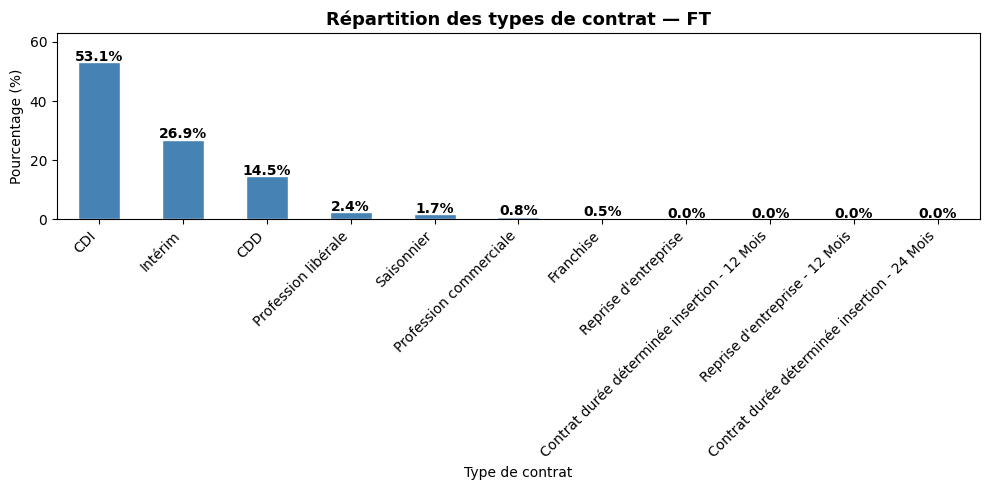

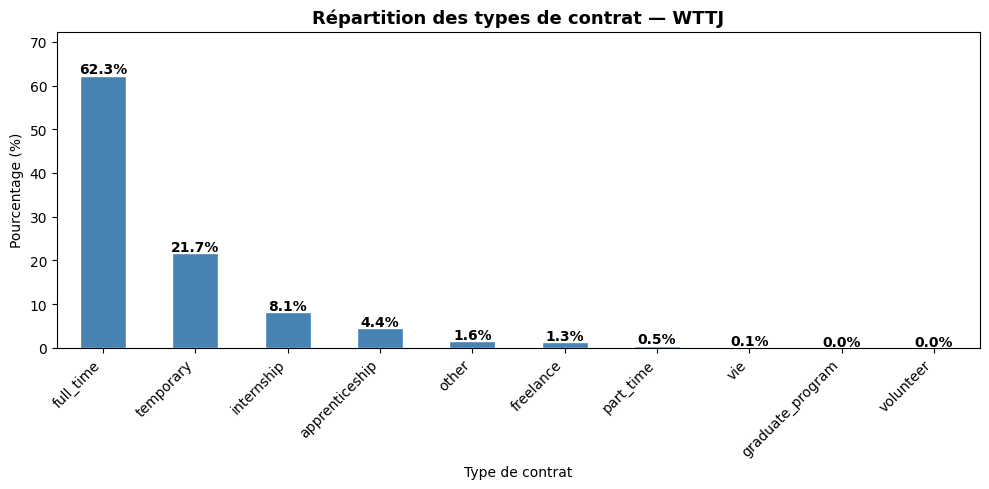

In [75]:
# Mapping des patterns => type normalisé
patterns = [
    (r'(?i)cdi',                'CDI'),
    (r'(?i)contrat à durée indéterminée',                'CDD'),
    (r'(?i)cdd',                'CDD'),
    (r'(?i)contrat à durée déterminée',                'CDD'),
    (r'(?i)profession\s+lib',   'Profession libérale'),
    (r'(?i)intér?im',           'Intérim'),
    (r'(?i)saisonnier',           'Saisonnier'),
    (r'(?i)profession commerciale',     'Profession commerciale'),
    (r'(?i)franchise',     'Franchise')    
]

# Apply
df_normalize = normalize_contracts(df, patterns)

df_normalize_contract_counts_by_source = df_normalize.groupby('source')['contract_normalized'].value_counts()
print(f"Modalités de contrats FT = {len(df_normalize_contract_counts_by_source.loc['FT'])}")
print(f"Modalités de contrats WTTJ = {len(df_normalize_contract_counts_by_source.loc['WTTJ'])}")

display(df_normalize_contract_counts_by_source.head(30))

plot_contract_by_source(df_normalize, 'FT', 'contract_normalized')
plot_contract_by_source(df_normalize, 'WTTJ', 'contract_normalized')


### Expérience

In [79]:
experience_level_counts_by_source = df.groupby('source')['experience_level'].value_counts()
experience_description_counts_by_source = df.groupby('source')['experience_description'].value_counts()

### Avant normalisation

**FT**
- experienceExige => D : débutant accepté, E : l’expérience est exigée, S : l’expérience est souhaitée
- experienceLibelle => Libellé de l’expérience ex : Débutant accepté / 1 ans ... 
- experienceCommentaire => Commentaire sur l’expérience. Ex: Expérience dans la vente souhaitée

On a pas la bonne correspondance de colonne.
Il faut prendre `experience_level` pour `wttj` et `experience_description` pour FT


In [80]:
display(experience_level_counts_by_source.head(30))


source  experience_level  
FT      E                     307688
        D                     279066
        S                         14
WTTJ    LESS_THAN_6_MONTHS     16688
        5_TO_7_YEARS            3132
        4_TO_5_YEARS            2890
        2_TO_3_YEARS            2480
        1_TO_2_YEARS            2095
        3_TO_4_YEARS            1830
        6_MONTHS_TO_1_YEAR      1136
        7_TO_10_YEARS            483
        10_TO_15_YEARS           461
        MORE_THAN_15_YEARS        31
Name: count, dtype: int64

In [81]:
display(experience_description_counts_by_source.head(30))

source  experience_description          
FT      Débutant accepté                    276159
        1 An(s)                              91518
        2 An(s)                              67695
        3 An(s)                              42951
        Expérience exigée                    35264
        5 An(s)                              19507
        6 Mois                                9175
        0 An(s)                               4707
        12 Mois                               3976
        6 An(s)                               3660
        4 An(s)                               2605
        24 Mois                               1867
        3 Mois                                1555
        10 An(s)                              1335
        7 An(s)                               1233
        1 Mois                                 859
        36 Mois                                553
        2 Mois                                 523
        8 An(s)                          

In [106]:
# Définition des tranches d'expérience avec leurs indices
EXPERIENCE_LEVELS = [
    (0, 'Débutant',    [r'(?i)débutant', r'(?i)0 an', r'(?i)sans expérience']),
    (1, '0-1 an',      [r'(?i)^1 an', r'(?i)^6 mois', r'(?i)^1 mois', r'(?i)^3 mois', r'(?i)less_than_6_months', r'(?i)6_months_to_1_year']),
    (2, '1-2 ans',     [r'(?i)^2 an', r'(?i)1_to_2_years']),
    (3, '2-3 ans',     [r'(?i)^3 an', r'(?i)^24 mois', r'(?i)2_to_3_years' ]),
    (4, '3-5 ans',     [r'(?i)^4 an', r'(?i)^5 an', r'(?i)4_to_5_years', r'(?i)3_to_4_years']),
    (5, '5-10 ans',    [r'(?i)^6 an', r'(?i)^7 an', r'(?i)^8 an', r'(?i)^9 an', r'(?i)^10 an', r'(?i)5_to_7_years', r'(?i)7_to_10_years']),
    (6, '10+ ans',     [r'(?i)^1[1-9] an', r'(?i)^[2-9][0-9] an', r'(?i)10_to_15_years', r'(?i)more_than_15_years']),
    (-1, 'Non précisé', [r'(?i)expérience exigée', r'(?i)expérience souhaitée']),
   
]

def normalize_experience(df, experience_col):
    """
    Normalise les niveaux d'expérience :
    - experience_normalized : label lisible (ex: '0-1 an')
    - experience_index      : indice numérique (ex: 1) pour trier/comparer
    - experience_detail     : valeur originale nettoyée
    """

    def extract_experience(value):
        if pd.isna(value):
            #To DEBUG
            return -1, 'NAN', None
            #return -1, 'Non précisé', None
        
        str_value = str(value).strip()
        
        for index, label, patterns in EXPERIENCE_LEVELS:
            for pattern in patterns:
                if re.search(pattern, str_value):
                    # Détail = valeur originale
                    return index, label, str_value
        
        #return -1, 'Non précisé', str_value
        # To debug
        return -1, value, str_value
    

    results = df[experience_col].apply(extract_experience)
    
    df = df.copy()
    df['experience_index']      = results.apply(lambda x: x[0])
    df['experience_normalized'] = results.apply(lambda x: x[1])
    df['experience_detail']     = results.apply(lambda x: x[2])
    
    return df


In [107]:
def get_experience_col(row):
    if row['source'] == 'FT':
        return row['experience_description']
    elif row['source'] == 'WTTJ':
        return row['experience_level']
    else:
        return None 

df_normalize['experience_source_composite'] = df.apply(get_experience_col, axis=1)

# Utilisation
df_normalize = normalize_experience(df_normalize,'experience_source_composite')

# Vérification
#df_normalize[['experience_source_composite', 'experience_index', 'experience_normalized', 'experience_detail']].head(20)

display(df_normalize.groupby('source')['experience_normalized'].value_counts())

source  experience_normalized
FT      Débutant                 285311
        0-1 an                   112006
        1-2 ans                   71678
        2-3 ans                   46660
        Non précisé               35282
                                  ...  
WTTJ    3-5 ans                    4720
        5-10 ans                   3615
        2-3 ans                    2480
        1-2 ans                    2095
        10+ ans                     492
Name: count, Length: 434, dtype: int64

## ROME

In [24]:
rome_count = df['rome_code'].value_counts()


## Statistics from helper

In [108]:
if df is not None and not df.empty:
    merge_utils.print_statistics(df)
else    :
    logger.warning("⚠️ Aucune donnée chargée pour les statistiques FT/WTTJ fusionnées")


📊 STATISTICS OF THE MERGED DATASET

📈 GLOBAL STATISTICS
   Total offers: 638,047

📦 DISTRIBUTION BY SOURCE
   FT: 586,768 offers (92.0%)
   WTTJ: 51,279 offers (8.0%)

📌 ROME COVERAGE BY SOURCE
   FT: 586,768/586,768 offers with ROME (100.0%)
   WTTJ: 51,279/51,279 offers with ROME (100.0%)

🎯 ROME CODES
   Offers with ROME: 638,047 (100.0%)
   Unique ROME codes: 1506

🏆 TOP 10 ROME CODES
   K1304: 11,963 (1.9%) - Employé familial / Employée familiale
   J1501: 10,656 (1.7%) - Aide-soignant / Aide-soignante
   J1506: 10,652 (1.7%) - Infirmier / Infirmière en soins généraux (IDE)
   C1504: 10,488 (1.6%) - Conseiller / Conseillère immobilier
   M1211: 9,968 (1.6%) - Expert-comptable / Experte-comptable
   M1203: 9,046 (1.4%) - Comptable
   I1304: 7,599 (1.2%) - Technicien / Technicienne de maintenance industrielle
   K1311: 7,492 (1.2%) - Assistant / Assistante de vie aux familles
   D1507: 7,287 (1.1%) - Employé / Employée de rayon libre-service
   H2903: 6,829 (1.1%) - Tourneur-fraise